### Part A: Note on Interpretations
- All interpretations, observations, and discussions presented in this notebook are based on the outputs, plots, summary statistics, and model results generated as of **April 14, 2026**..

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
%matplotlib inline

#### Important Points for the Next Cell
- NIFTY50 constituent list is being fetched directly from the NSE archives to ensure the universe is updated.
- Since yfinance is being used for price data, ".NS" is appended to each symbol retrieved from the NSE list

In [3]:
def get_live_nifty50_tickers():
    url = "https://nsearchives.nseindia.com/content/indices/ind_nifty50list.csv"

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36",
        "Accept-Language": "en-US, en;q=0.5",
        "Referer": "https://www.nseindia.com/market-data/live-equity-market"
    }

    with requests.Session() as session:
        session.headers.update(headers)
        session.get("https://www.nseindia.com", timeout=5) 
        response = session.get(url, timeout=10)
        
        if response.status_code == 200:
            csv_content = response.content.decode('utf-8')
            df_nse = pd.read_csv(StringIO(csv_content))
            tickers = [symbol + ".NS" for symbol in df_nse['Symbol']]
            print(f"Successfully retrieved {len(tickers)} tickers.")
            return tickers
        else:
            print(f"Failed to retrieve data. Status code: {response.status_code}")
            return []

nifty50_list = get_live_nifty50_tickers()

Successfully retrieved 50 tickers.


In [4]:
if nifty50_list:
    print(f"Successfully retrieved {len(nifty50_list)} tickers:")
    print(nifty50_list)

Successfully retrieved 50 tickers:
['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BHARTIARTL.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'ETERNAL.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS', 'INFY.NS', 'INDIGO.NS', 'JSWSTEEL.NS', 'JIOFIN.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'MAXHEALTH.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TMPV.NS', 'TATASTEEL.NS', 'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS']


#### If the above query failed to fetch the list of NIFTY50 stocks, uncomment the cell below to use the output we got.

In [5]:
# if nifty50_list is None:
#     nifty50_list = [
#         'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 
#         'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BHARTIARTL.NS', 
#         'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'ETERNAL.NS', 
#         'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HINDALCO.NS', 
#         'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS', 'INFY.NS', 'INDIGO.NS', 
#         'JSWSTEEL.NS', 'JIOFIN.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 
#         'MARUTI.NS', 'MAXHEALTH.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS', 
#         'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 
#         'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TMPV.NS', 'TATASTEEL.NS', 
#         'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS'
#     ]

#### Using Average Daily Turnover to Select Our 2 Stocks
- We extract 6 months of daily Close and Volume data for the NIFTY50 universe
- For each trading day, Daily Turnover = Price * Volume (We have distinguished this from "Turnover Ratio" based on the difference in terminology used in the problem statement).
- So, the terms "Traded Value", "Trading Activity" and "Turnover" are used interchangeably in our assignment and differ from the proxy "Turnover Ratio"
- Average the daily turnover over the 6 month period
- Check the Top 25% and Bottom 25% stocks

In [6]:
end_date = "2026-04-14"
start_date = (pd.Timestamp(end_date) - pd.DateOffset(months=6)).strftime("%Y-%m-%d")

In [7]:
raw_data = yf.download(nifty50_list, start=start_date, end=end_date, interval="1d", progress=True, threads=True)

turnover_stats = {}
for ticker in nifty50_list:
    try:
        daily_turnover = raw_data['Close'][ticker] * raw_data['Volume'][ticker]
        turnover_stats[ticker] = daily_turnover.mean()
    except Exception:
        continue

turnover_df = pd.DataFrame.from_dict(turnover_stats, orient='index', columns=['Avg_Daily_Turnover'])
turnover_df = turnover_df.sort_values(by='Avg_Daily_Turnover', ascending=False)

q3_threshold = turnover_df['Avg_Daily_Turnover'].quantile(0.75)
q1_threshold = turnover_df['Avg_Daily_Turnover'].quantile(0.25)

top_25 = turnover_df[turnover_df['Avg_Daily_Turnover'] >= q3_threshold]
bottom_25 = turnover_df[turnover_df['Avg_Daily_Turnover'] <= q1_threshold]

print("TOP 25% (Highly Liquid)")
display(top_25)

print("BOTTOM 25% (Relatively Illiquid)")
display(bottom_25)

C:\Users\Jairam Ayyar\AppData\Local\Temp\ipykernel_13452\1350737170.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(nifty50_list, start=start_date, end=end_date, interval="1d", progress=True, threads=True)
[*********************100%***********************]  50 of 50 completed


TOP 25% (Highly Liquid)


,Avg_Daily_Turnover
HDFCBANK.NS,2.759041e+10
RELIANCE.NS,1.924422e+10
ICICIBANK.NS,1.885855e+10
BHARTIARTL.NS,1.573180e+10
INFY.NS,1.512904e+10
SBIN.NS,1.313820e+10
ETERNAL.NS,1.174733e+10
TCS.NS,9.748333e+09
LT.NS,9.541429e+09
M&M.NS,8.694041e+09


BOTTOM 25% (Relatively Illiquid)


,Avg_Daily_Turnover
TECHM.NS,3.108288e+09
MAXHEALTH.NS,2.943519e+09
WIPRO.NS,2.941724e+09
APOLLOHOSP.NS,2.894539e+09
BAJAJFINSV.NS,2.355026e+09
CIPLA.NS,2.268748e+09
DRREDDY.NS,2.155187e+09
HDFCLIFE.NS,2.104520e+09
JSWSTEEL.NS,1.987293e+09
GRASIM.NS,1.969603e+09


#### Stock Selection Justification
- Most liquid and most relatively illiquid stocks

In [8]:
liquid_stock = "HDFCBANK.NS"
illiquid_stock = "NESTLEIND.NS"

#### Calculation of Log Returns
Log returns are computed as r_t = ln(P_t / P_{t-1})

In [9]:
df_liq = pd.DataFrame({
    'Close': raw_data['Close'][liquid_stock],
    'Volume': raw_data['Volume'][liquid_stock]
}).copy()

df_illiq = pd.DataFrame({
    'Close': raw_data['Close'][illiquid_stock],
    'Volume': raw_data['Volume'][illiquid_stock]
}).copy()

df_liq['Log_Return'] = np.log(df_liq['Close'] / df_liq['Close'].shift(1))
df_illiq['Log_Return'] = np.log(df_illiq['Close'] / df_illiq['Close'].shift(1))

df_liq.dropna(inplace=True)
df_illiq.dropna(inplace=True)

print(f"Daily Log Returns - Liquid Stock {liquid_stock}")
display(df_liq[['Close', 'Log_Return']].head())
print(f"Daily Log Returns - Illiquid Stock {illiquid_stock}")
display(df_illiq[['Close', 'Log_Return']].head())

Daily Log Returns - Liquid Stock HDFCBANK.NS


,Close,Log_Return
Date,,
2025-10-15,978.250000,0.001125
2025-10-16,994.349976,0.016324
2025-10-17,1002.549988,0.008213
2025-10-20,1002.950012,0.000399
2025-10-21,1007.700012,0.004725


Daily Log Returns - Illiquid Stock NESTLEIND.NS


,Close,Log_Return
Date,,
2025-10-15,1214.840942,0.038304
2025-10-16,1269.744507,0.044203
2025-10-17,1282.575195,0.010054
2025-10-20,1278.497192,-0.003185
2025-10-21,1280.387085,0.001477


#### Calculation of Rolling Realized Volatility (20 day window, given)
- First, we calculate the standard deviation of daily log returns over the sliding window of the previous 20 trading days.
- This is converted into annualized volatility by multiplying with sqrt(252).
- Assumption of 252 trading days in a year

In [10]:
window_size = 20

df_liq['Rolling_Volatility'] = df_liq['Log_Return'].rolling(window=window_size).std() * np.sqrt(252)
df_illiq['Rolling_Volatility'] = df_illiq['Log_Return'].rolling(window=window_size).std() * np.sqrt(252)

print(f"Rolling 20-day Volatility - Liquid Stock {liquid_stock}")
display(df_liq[['Log_Return', 'Rolling_Volatility']].tail())
print(f"Rolling 20-day Volatility - Illiquid Stock {illiquid_stock}")
display(df_illiq[['Log_Return', 'Rolling_Volatility']].tail())

Rolling 20-day Volatility - Liquid Stock HDFCBANK.NS


,Log_Return,Rolling_Volatility
Date,,
2026-04-07,0.001296,0.400586
2026-04-08,0.055552,0.450761
2026-04-09,-0.022804,0.452685
2026-04-10,0.015672,0.455095
2026-04-13,-0.019440,0.455588


Rolling 20-day Volatility - Illiquid Stock NESTLEIND.NS


,Log_Return,Rolling_Volatility
Date,,
2026-04-07,0.005577,0.194370
2026-04-08,-0.007470,0.195421
2026-04-09,0.012283,0.196114
2026-04-10,0.016627,0.204619
2026-04-13,-0.018745,0.214581


#### Liquidity Proxies: Formulas and Assumptions
To analyze the liquidity of the selected stocks, we implement two distinct proxies as defined in the class materials:

**1. Turnover Ratio (TR)**
The Turnover Ratio measures how frequently a stock's total shares are traded in the market.
$$TR = \frac{\sum_{d=1}^{D_{iym}} (VOL_{iymd})}{NSO_{iym}}$$
* **Numerator ($\sum VOL$):** Represents the monthly sum of the total number of shares traded.
* **Denominator ($NSO$):** Represents the total Number of Shares Outstanding for the stock $i$ in month $m$ of year $y$.
* **Assumption:** We assume the Number of Shares Outstanding ($NSO$) remains constant over our 6-month analysis period.

**2. Amihud (2002) Illiquidity (ILLIQ)**
The Amihud ratio measures the price impact of a trade. It identifies how much the stock price moves for every unit of currency (Rupee) traded.
$$ILLIQ = \frac{1}{D_i} \sum_{d=1}^{D_i} \frac{|R_{iymd}|}{TV_{iymd}}$$
* **Numerator ($|R_{iymd}|$):** The absolute return of stock $i$ for a specific day $d$.
* **Denominator ($TV_{iymd}$):** The traded volume in value (Price $\times$ Volume) for that specific day.
* **$D_i$:** The total number of trading days in the month/period used to average the daily impacts.
* **Interpretation:** Higher values of ILLIQ indicate greater illiquidity, as it suggests the price is more sensitive to trading volume.

In [11]:
nso_liq = yf.Ticker(liquid_stock).info.get('sharesOutstanding')
nso_illiq = yf.Ticker(illiquid_stock).info.get('sharesOutstanding')

def calculate_proxies(df, nso):
    df['TV'] = df['Close'] * df['Volume']
    df['Amihud_Daily'] = df['Log_Return'].abs() / df['TV']
    df['Turnover_Ratio_Daily'] = df['Volume'] / nso

    return df

In [12]:
df_liq = calculate_proxies(df_liq, nso_liq)
df_illiq = calculate_proxies(df_illiq, nso_illiq)

print(f"NSO Data - Liquid Stock {liquid_stock}")
print(f"{liquid_stock}: {nso_liq:,} shares")
print(f"NSO Data - Illiquid Stock {illiquid_stock}")
print(f"{illiquid_stock}: {nso_illiq:,} shares")

print(f"Calculated Liquidity Proxies - Liquid Stock {liquid_stock}")
display(df_liq[['TV', 'Amihud_Daily', 'Turnover_Ratio_Daily']].tail())
print(f"Calculated Liquidity Proxies - Illiquid Stock {illiquid_stock}")
display(df_illiq[['TV', 'Amihud_Daily', 'Turnover_Ratio_Daily']].tail())

NSO Data - Liquid Stock HDFCBANK.NS
HDFCBANK.NS: 15,393,260,762 shares
NSO Data - Illiquid Stock NESTLEIND.NS
NESTLEIND.NS: 1,928,314,320 shares
Calculated Liquidity Proxies - Liquid Stock HDFCBANK.NS


,TV,Amihud_Daily,Turnover_Ratio_Daily
Date,,,
2026-04-07,3.961116e+10,3.272251e-14,0.003333
2026-04-08,5.734695e+10,9.687057e-13,0.004565
2026-04-09,3.899109e+10,5.848583e-13,0.003175
2026-04-10,3.091783e+10,5.068898e-13,0.002479
2026-04-13,3.778745e+10,5.144521e-13,0.003089


Calculated Liquidity Proxies - Illiquid Stock NESTLEIND.NS


,TV,Amihud_Daily,Turnover_Ratio_Daily
Date,,,
2026-04-07,1.754334e+09,3.178737e-12,0.000744
2026-04-08,1.988793e+09,3.755970e-12,0.000850
2026-04-09,1.546484e+09,7.942636e-12,0.000653
2026-04-10,1.696937e+09,9.798110e-12,0.000704
2026-04-13,1.651411e+09,1.135093e-11,0.000698


#### Summary Statistics Calculation and Final Table

In [13]:
import scipy.stats as stats

def generate_summary_stats(df, label, ticker):
    stats_data = {
        'Mean Daily Log Return': df['Log_Return'].mean(),
        'Std Dev Log Return': df['Log_Return'].std(),
        'Skewness (Log Returns)': stats.skew(df['Log_Return']),
        'Kurtosis (Log Returns)': stats.kurtosis(df['Log_Return']),
        'Mean Annualized Volatility': df['Rolling_Volatility'].mean(),
        'Mean Amihud Ratio (ILLIQ)': df['Amihud_Daily'].mean(),
        'Mean Daily Turnover Ratio (TR)': df['Turnover_Ratio_Daily'].mean(),
        'Avg Daily Traded Value (INR)': df['TV'].mean()
    }
    return pd.Series(stats_data, name=f"{label} ({ticker})")

In [14]:
summary_table = pd.concat([
    generate_summary_stats(df_liq, "Liquid", liquid_stock),
    generate_summary_stats(df_illiq, "Illiquid", illiquid_stock)
], axis=1)

print("Summary Statistics: Liquid vs. Illiquid Stock Comparison")
display(summary_table)

Summary Statistics: Liquid vs. Illiquid Stock Comparison


,Liquid (HDFCBANK.NS),Illiquid (NESTLEIND.NS)
Mean Daily Log Return,-1.708062e-03,3.928051e-04
Std Dev Log Return,1.412374e-02,1.162464e-02
Skewness (Log Returns),-1.217482e-01,6.694667e-01
Kurtosis (Log Returns),3.466592e+00,1.960953e+00
Mean Annualized Volatility,1.724720e-01,1.606208e-01
Mean Amihud Ratio (ILLIQ),3.521571e-13,6.380838e-12
Mean Daily Turnover Ratio (TR),2.011574e-03,5.812863e-04
Avg Daily Traded Value (INR),2.763322e+10,1.412273e+09


#### Correlation Analysis and Visualization Plots

In [15]:
corr_liq = df_liq[['Rolling_Volatility', 'Amihud_Daily', 'Turnover_Ratio_Daily']].corr()
corr_illiq = df_illiq[['Rolling_Volatility', 'Amihud_Daily', 'Turnover_Ratio_Daily']].corr()

vol_amihud_liq = corr_liq.loc['Rolling_Volatility', 'Amihud_Daily']
vol_amihud_illiq = corr_illiq.loc['Rolling_Volatility', 'Amihud_Daily']

In [16]:
correlation_summary = pd.DataFrame({
    'Metric': ['Volatility vs Amihud', 'Volatility vs Turnover Ratio'],
    f'Liquid ({liquid_stock})': [
        corr_liq.loc['Rolling_Volatility', 'Amihud_Daily'],
        corr_liq.loc['Rolling_Volatility', 'Turnover_Ratio_Daily']
    ],
    f'Illiquid ({illiquid_stock})': [
        corr_illiq.loc['Rolling_Volatility', 'Amihud_Daily'],
        corr_illiq.loc['Rolling_Volatility', 'Turnover_Ratio_Daily']
    ]
})

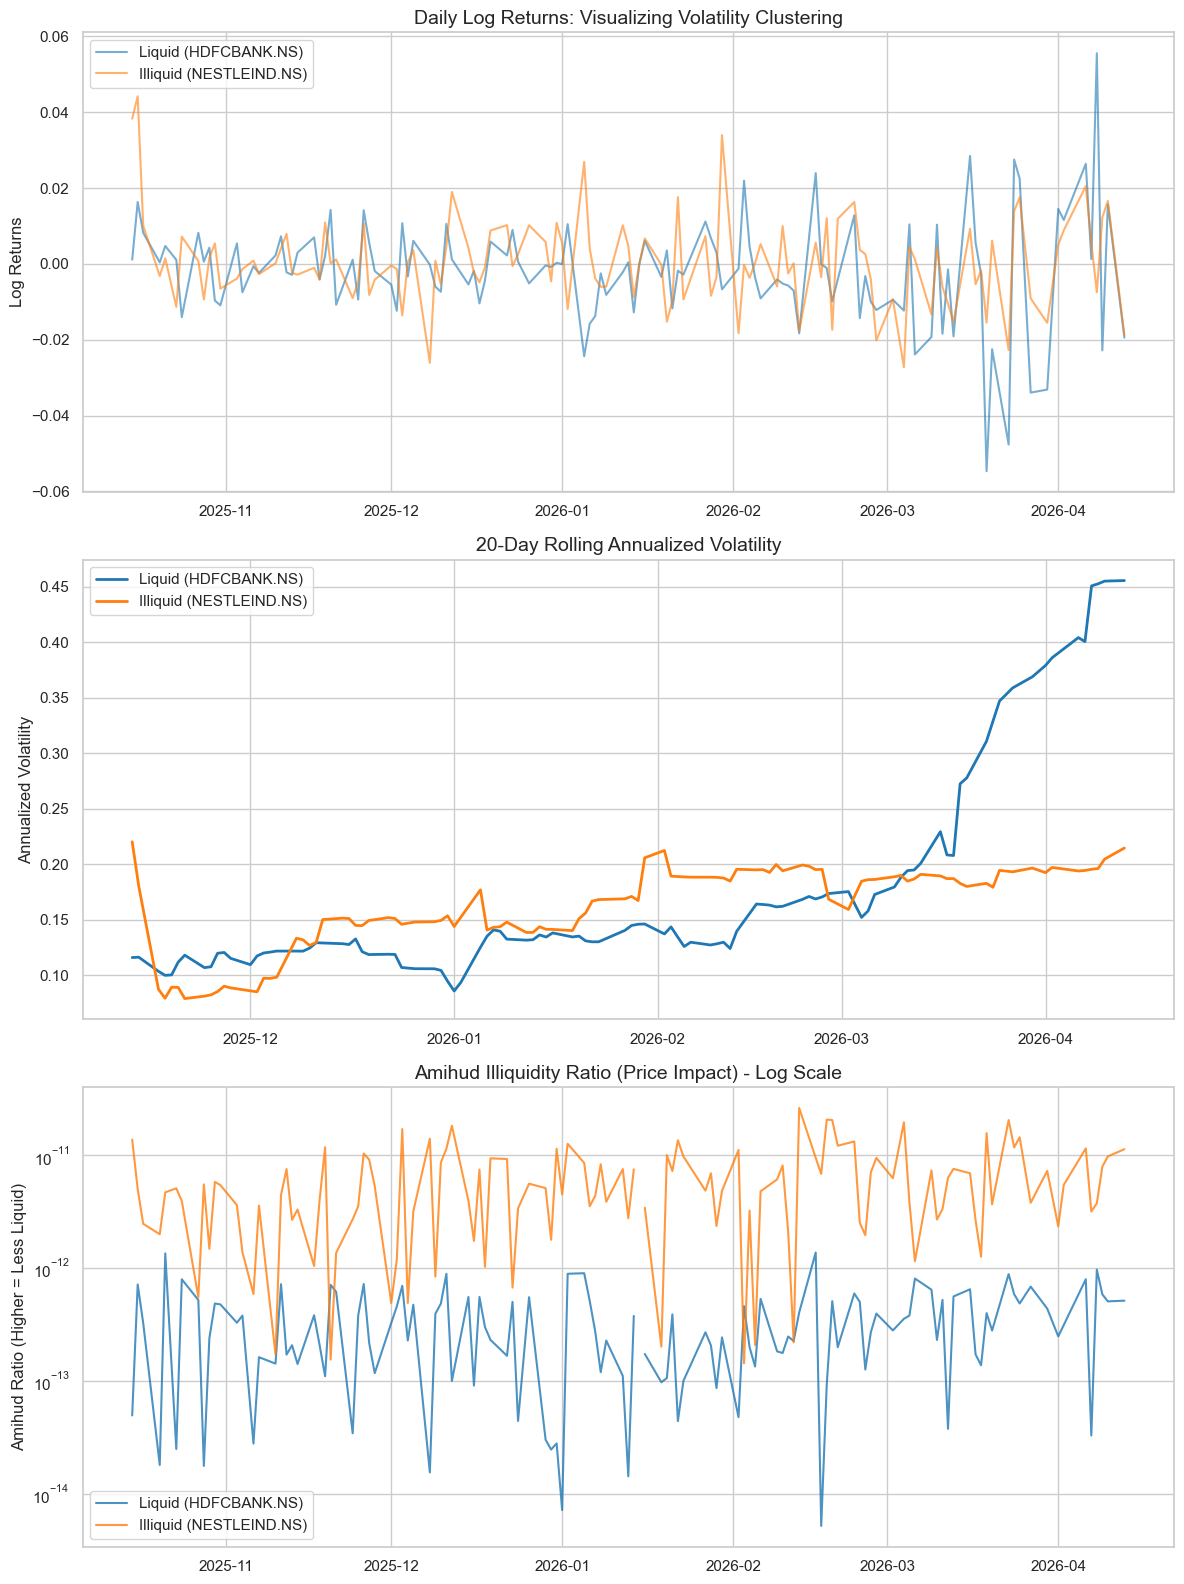

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

axes[0].plot(df_liq.index, df_liq['Log_Return'], label=f'Liquid ({liquid_stock})', alpha=0.6, color='tab:blue')
axes[0].plot(df_illiq.index, df_illiq['Log_Return'], label=f'Illiquid ({illiquid_stock})', alpha=0.6, color='tab:orange')
axes[0].set_title('Daily Log Returns: Visualizing Volatility Clustering', fontsize=14)
axes[0].set_ylabel('Log Returns')
axes[0].legend()

axes[1].plot(df_liq.index, df_liq['Rolling_Volatility'], label=f'Liquid ({liquid_stock})', lw=2, color='tab:blue')
axes[1].plot(df_illiq.index, df_illiq['Rolling_Volatility'], label=f'Illiquid ({illiquid_stock})', lw=2, color='tab:orange')
axes[1].set_title('20-Day Rolling Annualized Volatility', fontsize=14)
axes[1].set_ylabel('Annualized Volatility')
axes[1].legend()

axes[2].plot(df_liq.index, df_liq['Amihud_Daily'], label=f'Liquid ({liquid_stock})', alpha=0.8, color='tab:blue')
axes[2].plot(df_illiq.index, df_illiq['Amihud_Daily'], label=f'Illiquid ({illiquid_stock})', alpha=0.8, color='tab:orange')
axes[2].set_yscale('log')
axes[2].set_title('Amihud Illiquidity Ratio (Price Impact) - Log Scale', fontsize=14)
axes[2].set_ylabel('Amihud Ratio (Higher = Less Liquid)')
axes[2].legend()

plt.tight_layout()
plt.show()

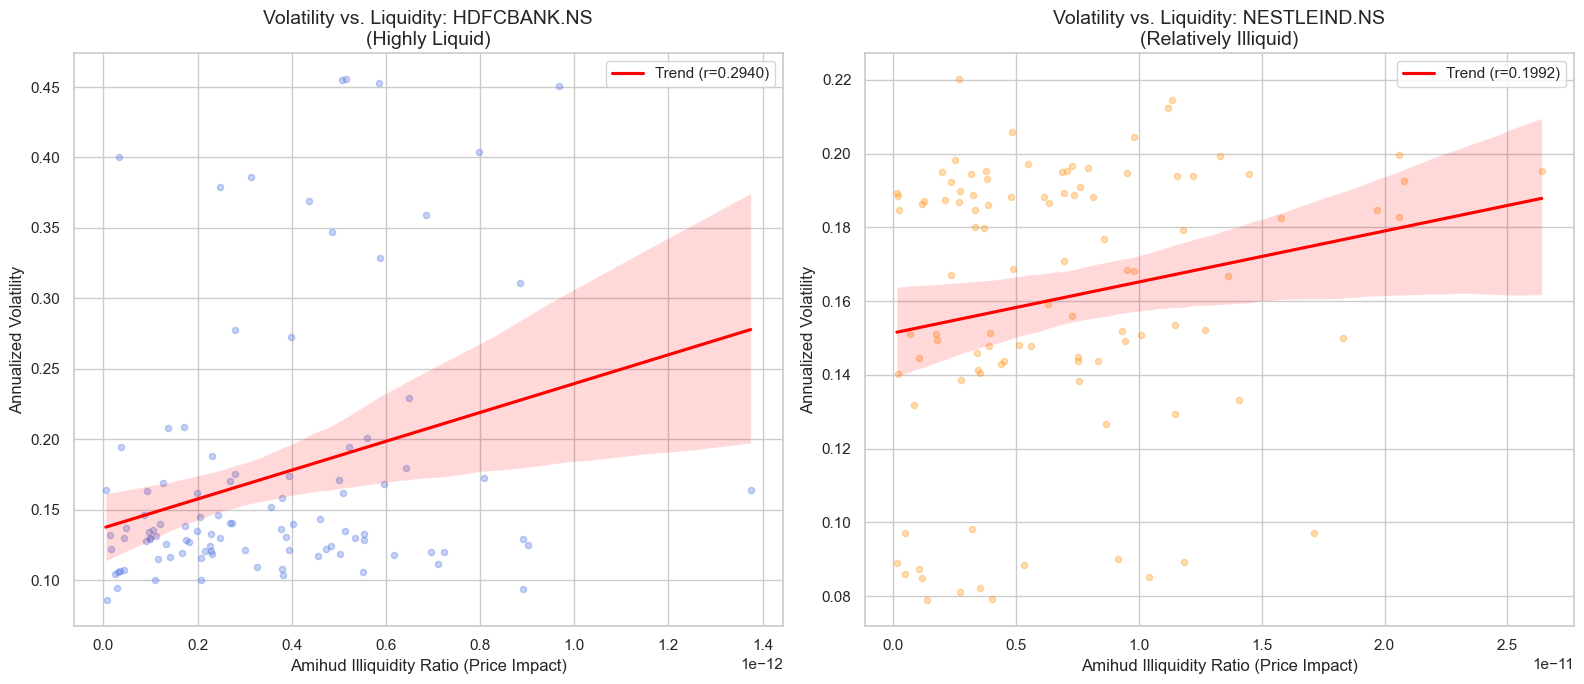

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.regplot(x='Amihud_Daily', y='Rolling_Volatility', data=df_liq, 
            ax=axes[0], color='royalblue', scatter_kws={'alpha':0.3, 's':20}, 
            line_kws={'color':'red', 'label': f'Trend (r={vol_amihud_liq:.4f})'})
axes[0].set_title(f'Volatility vs. Liquidity: {liquid_stock}\n(Highly Liquid)', fontsize=14)
axes[0].set_xlabel('Amihud Illiquidity Ratio (Price Impact)', fontsize=12)
axes[0].set_ylabel('Annualized Volatility', fontsize=12)
axes[0].legend()

sns.regplot(x='Amihud_Daily', y='Rolling_Volatility', data=df_illiq, 
            ax=axes[1], color='darkorange', scatter_kws={'alpha':0.3, 's':20}, 
            line_kws={'color':'red', 'label': f'Trend (r={vol_amihud_illiq:.4f})'})
axes[1].set_title(f'Volatility vs. Liquidity: {illiquid_stock}\n(Relatively Illiquid)', fontsize=14)
axes[1].set_xlabel('Amihud Illiquidity Ratio (Price Impact)', fontsize=12)
axes[1].set_ylabel('Annualized Volatility', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
print("Final Correlation Analysis")
display(correlation_summary.style.background_gradient(cmap='RdYlGn', axis=None))

Final Correlation Analysis


,Metric,Liquid (HDFCBANK.NS),Illiquid (NESTLEIND.NS)
0,Volatility vs Amihud,0.293962,0.199158
1,Volatility vs Turnover Ratio,0.615712,0.225110


### Volatility Clustering Analysis
#### Preliminary Tests

In [20]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

def run_diagnostics(df, ticker):
    returns = df['Log_Return'].dropna()
    print(f"DIAGNOSTIC TESTS: {ticker}")
    
    adf = adfuller(returns)
    stat_status = "Detected" if adf[1] < 0.05 else "Not Detected"
    print(f"Stationarity: {stat_status} (p-value: {adf[1]:.4e})")
    
    lb_ret = acorr_ljungbox(returns, lags=[10])
    lb_ret_p = lb_ret['lb_pvalue'].iloc[0] if hasattr(lb_ret, 'iloc') else lb_ret[1][0]
    ret_corr_status = "Detected" if lb_ret_p < 0.05 else "Not Detected"
    print(f"Serial Correlation in Returns: {ret_corr_status} (p-value: {lb_ret_p:.4e})")
    
    lb_sq = acorr_ljungbox(returns**2, lags=[10])
    lb_sq_p = lb_sq['lb_pvalue'].iloc[0] if hasattr(lb_sq, 'iloc') else lb_sq[1][0]
    vol_cluster_status = "Detected" if lb_sq_p < 0.05 else "Not Detected"
    print(f"Volatility Clustering (LB): {vol_cluster_status} (p-value: {lb_sq_p:.4e})")
    
    arch = het_arch(returns)
    arch_status = "Detected" if arch[1] < 0.05 else "Not Detected"
    print(f"ARCH Effects (Engle): {arch_status} (p-value: {arch[1]:.4e})")

In [21]:
run_diagnostics(df_liq, f"Liquid ({liquid_stock})")

DIAGNOSTIC TESTS: Liquid (HDFCBANK.NS)
Stationarity: Not Detected (p-value: 2.8179e-01)
Serial Correlation in Returns: Not Detected (p-value: 1.6442e-01)
Volatility Clustering (LB): Detected (p-value: 2.2795e-14)
ARCH Effects (Engle): Detected (p-value: 1.4042e-08)


In [22]:
run_diagnostics(df_illiq, f"Illiquid ({illiquid_stock})")

DIAGNOSTIC TESTS: Illiquid (NESTLEIND.NS)
Stationarity: Detected (p-value: 8.0151e-20)
Serial Correlation in Returns: Not Detected (p-value: 9.9544e-01)
Volatility Clustering (LB): Not Detected (p-value: 3.2746e-01)
ARCH Effects (Engle): Not Detected (p-value: 9.9177e-01)


In [23]:
df_liq['Log_Return_Diff'] = df_liq['Log_Return'].diff().dropna()

print(f"Final Assumption Check: {liquid_stock}")

adf_diff = adfuller(df_liq['Log_Return_Diff'].dropna())
print(f"ADF p-value (Diffed Data): {adf_diff[1]:.4e}")
if adf_diff[1] < 0.05:
    print("Assumption 1: Stationarity DETECTED (via first differencing).")
else:
    print("Assumption 1: Stationarity NOT DETECTED.")

jb_stat, jb_p = stats.jarque_bera(df_liq['Log_Return'])
print(f"Jarque-Bera p-value: {jb_p:.4e}")
if jb_p < 0.05:
    print("Assumption 2: Normality REJECTED (Fat Tails detected).")
    print("Action: Use 'Student's t' (dist='t') in the GARCH model.")
else:
    print("Assumption 2: Normality DETECTED.")
    print("Action: Use 'Normal' (dist='norm') in the GARCH model.")

Final Assumption Check: HDFCBANK.NS
ADF p-value (Diffed Data): 1.2942e-08
Assumption 1: Stationarity DETECTED (via first differencing).
Jarque-Bera p-value: 6.0088e-14
Assumption 2: Normality REJECTED (Fat Tails detected).
Action: Use 'Student's t' (dist='t') in the GARCH model.


#### **Volatility Clustering Analysis: GARCH(1,1) Model**

In [24]:
from arch import arch_model

garch_data = df_liq['Log_Return_Diff'].dropna() * 100

model_hdfc = arch_model(garch_data, vol='Garch', p=1, q=1, dist='t')
garch_results = model_hdfc.fit(disp='off')

print(f"GARCH(1,1) Model Summary: {liquid_stock}")
print(garch_results.summary())

alpha = garch_results.params['alpha[1]']
beta = garch_results.params['beta[1]']
persistence = alpha + beta

print(f"\nKey Model Parameters")
print(f"Alpha (Shock Sensitivity): {alpha:.4f}")
print(f"Beta (Volatility Persistence): {beta:.4f}")
print(f"Total Persistence (Alpha + Beta): {persistence:.4f}")

GARCH(1,1) Model Summary: HDFCBANK.NS
                        Constant Mean - GARCH Model Results                         
Dep. Variable:              Log_Return_Diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -224.950
Distribution:      Standardized Student's t   AIC:                           459.901
Method:                  Maximum Likelihood   BIC:                           473.838
                                              No. Observations:                  120
Date:                      Tue, Apr 14 2026   Df Residuals:                      119
Time:                              19:10:19   Df Model:                            1
                                Mean Model                               
                  coef    std err          t      P>|t|  95.0% Conf. Int.
-------------------------------------------------

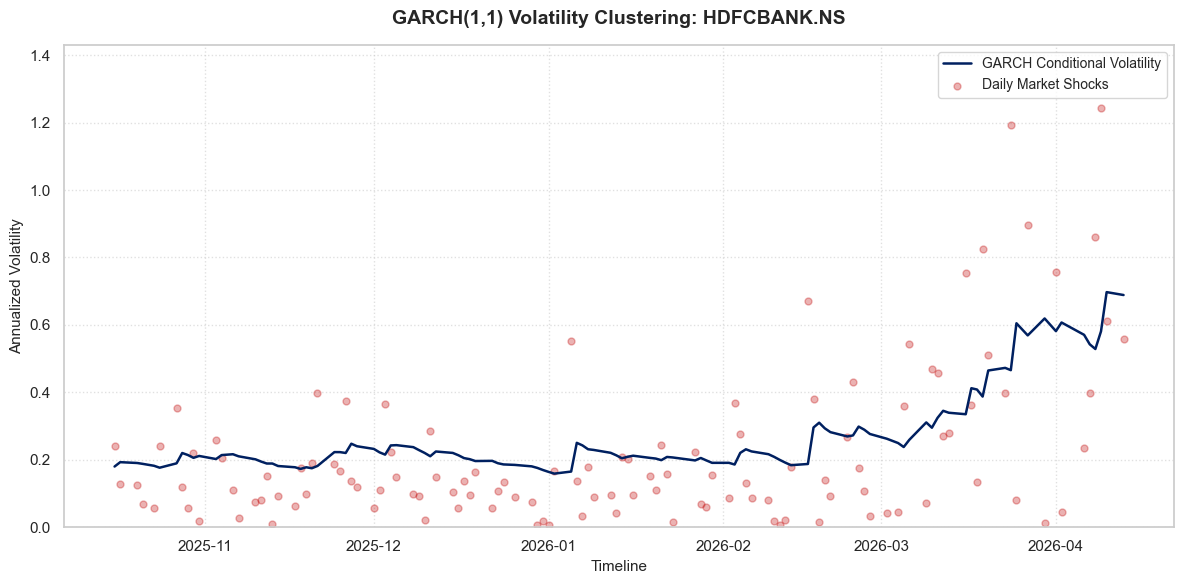

In [25]:
cond_vol = (garch_results.conditional_volatility / 100) * np.sqrt(252)
abs_shocks = df_liq.loc[cond_vol.index, 'Log_Return_Diff'].abs() * np.sqrt(252)

plt.figure(figsize=(12, 6)) 

plt.plot(cond_vol.index, cond_vol, color='#002060', lw=1.8, label='GARCH Conditional Volatility', zorder=3)
plt.scatter(cond_vol.index, abs_shocks, color='#C00000', alpha=0.3, s=25, label='Daily Market Shocks', zorder=2)

y_limit = max(abs_shocks.max(), cond_vol.max()) * 1.15
plt.ylim(0, y_limit)

plt.title(f"GARCH(1,1) Volatility Clustering: {liquid_stock}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline", fontsize=11)
plt.ylabel("Annualized Volatility", fontsize=11)
plt.legend(frameon=True, loc='best', fontsize=10)
plt.grid(visible=True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()